# Analisis Sentimen publik Program MBG di Youtube

Analisis sentimen adalah metode untuk mengklasifikasikan opini dalam bentuk teks menjadi kategori emosional seperti *positif*, *negatif*, atau *netral*. Pada proyek ini, dilakukan analisis terhadap **ulasan publik mengenai program mbg** yang diambil langsung dari Youtube melalui proses scraping menggunakan Python.

**Dataset:**
- **Sumber Data:** Youtube (scraping manual dari aplikasi Youtube)
- **Jumlah Data Awal:** 8662
 ulasan
- **Distribusi Kelas:**
  - **Negatif:** ± 3030
  - **Positif:** ± 2873
  - **Netral:** ± 2599

## Import Library dan Data

In [35]:
!pip install nltk --q
!pip install transformers --q
!pip install Sastrawi --q
!pip install -q keras-tuner

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import re, string, requests
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import torch
from io import StringIO
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from google.colab import drive
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('popular', halt_on_error=False)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_dat

True

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
df = pd.read_excel('/content/drive/My Drive/all_data/MBG_scraping.xlsx')
print("Jumlah data (total):", len(df))
print("\nSampel data:")
df.head()

Jumlah data (total): 8661

Sampel data:


,Review
0,luar biasa paparannya
1,yang jadi pertimbangan bukan nilai gizi dan ke...
2,bersyukur kita punya ibu ini
3,sesuai apa yang saya pikirkan. bahwa bgn palin...
4,sarang tikus2 kantor


## Preprosessing Data

In [39]:
print(f"Total baris data: {df.shape[0]}, Kolom: {df.shape[1]}")

Total baris data: 8661, Kolom: 1


In [40]:
df.isna().sum()

,0
Review,0


In [41]:
df.duplicated().sum()

np.int64(159)

In [42]:
df.drop_duplicates(inplace=True)
print(f"Data count after removing duplicates: {len(df)}")

Data count after removing duplicates: 8502


In [43]:
df.describe()

,Review
count,8502
unique,8502
top,Sebenarnya ini kesempatan utk menguliti si bot...
freq,1


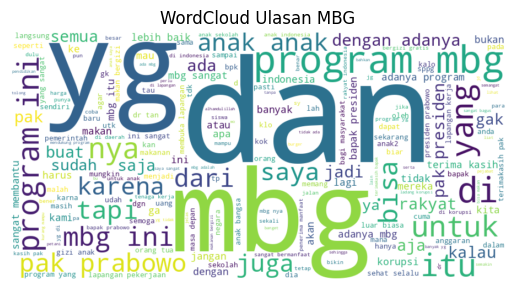

In [44]:
text_combined = ' '.join(df['Review'].astype(str))
cloud = WordCloud(width=900, height=450, background_color='white').generate(text_combined)
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Ulasan MBG')
plt.show()

In [45]:
def bersihkan_teks(teks):
    teks = re.sub(r'@\w+', '', teks)               # Mention
    teks = re.sub(r'#\w+', '', teks)               # Hashtag
    teks = re.sub(r'RT[\s]+', '', teks)            # Retweet
    teks = re.sub(r"http\S+", '', teks)            # Link
    teks = re.sub(r'[0-9]+', '', teks)             # Angka
    teks = re.sub(r'[^\w\s]', '', teks)            # Simbol
    teks = teks.replace('\n', ' ').strip()
    return teks.translate(str.maketrans('', '', string.punctuation))

In [46]:
def huruf_kecil(teks):
    return teks.lower()

In [47]:
kamus_slang = {
    "abis": "habis", "bgt": "banget", "tp": "tapi", "tdk": "tidak", "gk": "tidak","ga": "tidak", "gak": "tidak", "gk": "tidak", "tdk": "tidak","aku": "saya", "gua": "saya", "lu": "kamu", "loe": "kamu","sampe":"sampai","stop":"hentikan",
    "aja": "saja", "banget": "sekali", "bgt": "sekali","dgn": "dengan", "dg": "dengan", "dlm": "dalam","korup": "korupsi","wkwk": "oke","bgs":"bagus","tp": "tetapi", "krn": "karena", "krna": "karena","gatot":"gagal total",
    "yg": "yang", "utk": "untuk", "dr": "dari", "dl": "dalam","tdk": "tidak", "trs": "terus", "sm": "sama", "sbg": "sebagai","bgt": "sekali", "bngt": "sekali", "bgtu": "begitu", "udh": "sudah","ggl":"gagal",
    "udah": "sudah", "dpt": "dapat", "klo": "kalau", "kalo": "kalau","msh": "masih", "jg": "juga", "jgn": "jangan", "blm": "belum","bs": "bisa", "bsa": "bisa", "krg": "kurang", "mkn": "makan","makanan": "makan",
    "minum": "minum", "ttp": "tetap", "spt": "seperti","dg": "dengan", "dr": "dari", "pd": "pada", "dl": "dalam","utk": "untuk", "org": "orang", "tdk": "tidak", "krn": "karena","bnyk": "banyak", "dpt": "dapat",
    "sdh": "sudah","nggak": "tidak", "ga": "tidak", "yg": "yang", "sy": "saya", "gue": "saya","udh": "sudah", "dr": "dari", "dgn": "dengan", "sm": "sama", "trus": "terus","kalo": "kalau", "pake": "pakai", "susah": "ribet", "bagus": "baik", "lol": "tertawa",
    "gmn": "gimana", "b aja": "biasa", "guna": "berguna", "td": "tadi", "krn": "karena","sbnrnya": "sebenarnya", "aj": "saja", "blm": "belum", "nyoba": "mencoba","error": "gangguan", "ok": "baik", "mantap": "bagus",
    "gaje": "tidak jelas", "notif": "notifikasi","gaje": "tidak jelas", "respon": "tanggapan","k*r*ps*":"korupsi","maling":"korupsi","amnh":"amanah","brk":"buruk","brgr":"burger","bdh":"bodoh","rcn":"racun","keracunan":"racun",
    "antri": "antre", "lamaa": "lama", "pelayanannya": "pelayanan","henti":"berhenti","gabisa": "tidak bisa", "gaboleh": "tidak boleh", "gabung": "bergabung","notif": "notifikasi", "fiturnya": "fitur", "rekom": "rekomendasi","gk usah":"tidak perlu","lnjt":"lanjut"
}
def ubah_kata_gaul(teks):
    return ' '.join([kamus_slang.get(kata, kata) for kata in teks.split()])

In [48]:
def tokenisasi(teks):
    return word_tokenize(teks)

In [49]:
stop_kata = set(stopwords.words('indonesian') + stopwords.words('english'))
tambahan_stop = [ 'saya', 'dan', 'yang', 'untuk', 'juga','aja', 'lagi', 'itu', 'karena', 'sudah', 'jadi', 'tapi', 'bisa','dokter', 'ada', 'ke', 'cepat','yang'
'dan', 'yg', 'mbg', 'ini', 'mbgnya', 'itu', 'di', 'untuk', 'saya', 'program', 'pak', 'prabowo', 'presiden', 'bisa', 'dari', 'tapi', 'juga', 'saja', 'aja', 'ada', 'karena', 'karna', 'dengan',
'sudah', 'jadi', 'buat', 'bapak', 'kita', 'ya', 'kalau', 'kalo', 'semua', 'dalam', 'akan', 'atau', 'ke', 'oleh', 'biar', 'kan', 'hanya', 'cuma', 'ga', 'gak', 'bukan', 'banyak', 'dr', 'lagi',
'pada', 'apa', 'utk', 'dgn', 'tp', 'jd', 'oleh','lah', 'nya']
stop_kata.update(tambahan_stop)
def hilangkan_stopwords(kata_token):
    return [kata for kata in kata_token if kata not in stop_kata]

In [50]:
def gabungkan_token(token_list):
    return ' '.join(token_list)

In [51]:
stemmer = StemmerFactory().create_stemmer()
def lakukan_stemming(teks):
    return stemmer.stem(teks)

In [52]:
df['bersihkan_text'] = df['Review'].astype(str).apply(bersihkan_teks)\
                                                  .apply(huruf_kecil)\
                                                  .apply(ubah_kata_gaul)\
                                                  .apply(tokenisasi)\
                                                  .apply(hilangkan_stopwords)\
                                                  .apply(gabungkan_token)\
                                                  .apply(lakukan_stemming)

In [53]:
lex_pos = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
lex_neg = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
df_pos = pd.read_csv(StringIO(lex_pos.text))
df_neg = pd.read_csv(StringIO(lex_neg.text))

pos_col = df_pos.columns[0]
neg_col = df_neg.columns[0]

positive_words = set(df_pos[pos_col])
negative_words = set(df_neg[neg_col])

def label_sentiment(text):
    tokens = text.split()
    pos_count = sum(1 for word in tokens if word in positive_words)
    neg_count = sum(1 for word in tokens if word in negative_words)
    if pos_count > neg_count:
        return 'positif'
    elif neg_count > pos_count:
        return 'negatif'
    else:
        return 'netral'

df['label'] = df['bersihkan_text'].apply(label_sentiment)
df = df[df['label'].isin(['positif', 'negatif', 'netral'])].copy()

Distribusi Sentimen:
label
negatif    3020
positif    2876
netral     2606
Name: count, dtype: int64


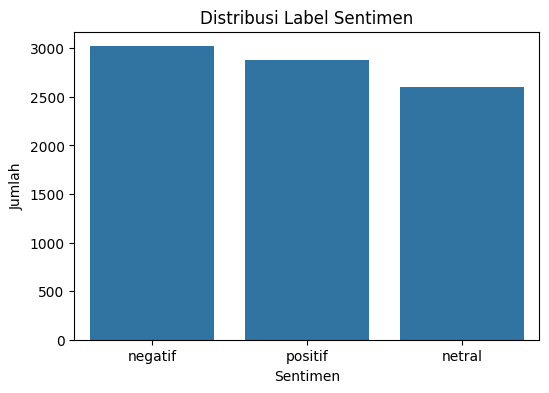

In [54]:
sentiment_counts = df['label'].value_counts()
print("Distribusi Sentimen:")
print(sentiment_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Distribusi Label Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

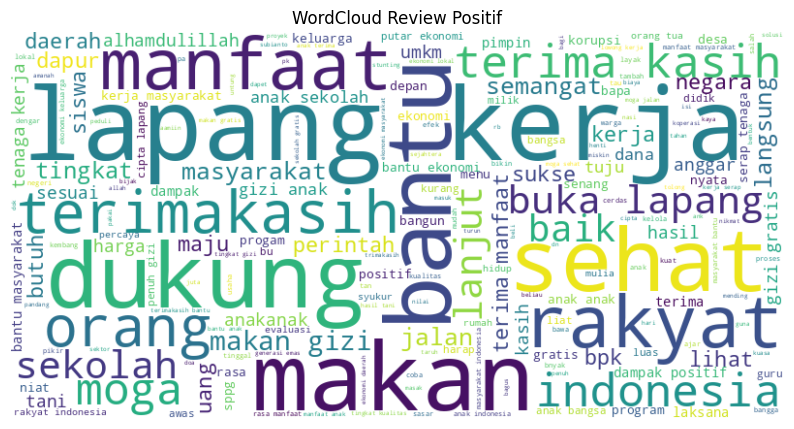

In [55]:
positive_reviews = df[df['label'] == 'positif']['bersihkan_text']

text_positive_combined = ' '.join(positive_reviews)

wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(text_positive_combined)

# Tampilkan WordCloud
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Review Positif')
plt.show()

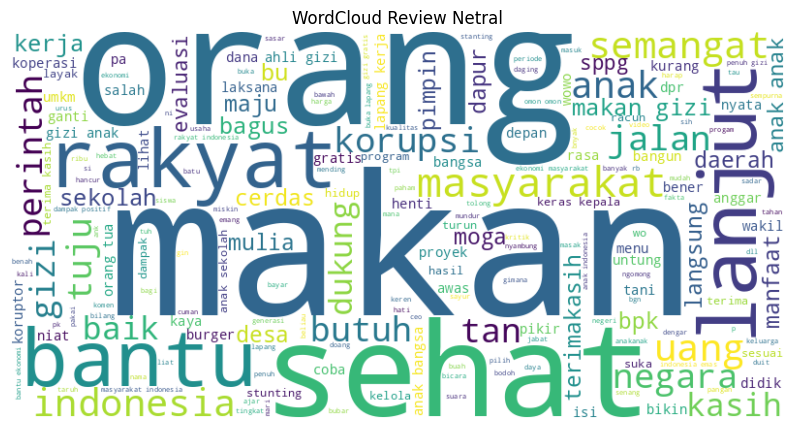

In [56]:
# Filter data untuk review netral
neutral_reviews = df[df['label'] == 'netral']['bersihkan_text']

# Gabungkan semua teks review netral
text_neutral_combined = ' '.join(neutral_reviews)

# Buat WordCloud untuk review netral
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white').generate(text_neutral_combined)

# Tampilkan WordCloud
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Review Netral')
plt.show()

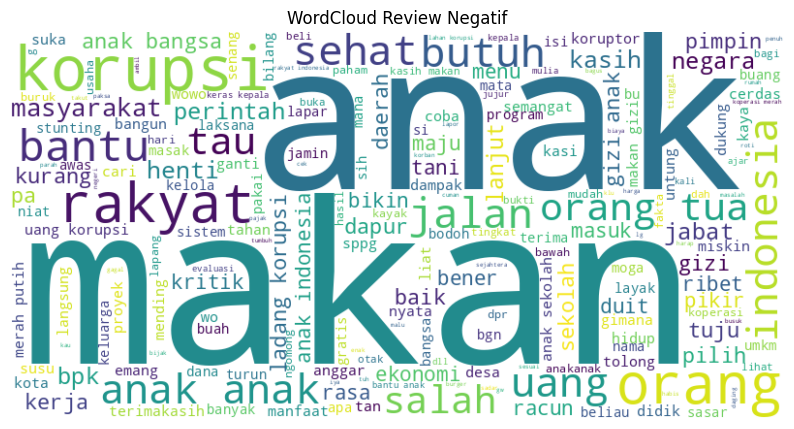

In [57]:
# Filter data untuk review negatif
negative_reviews = df[df['label'] == 'negatif']['bersihkan_text']

# Gabungkan semua teks review negatif
text_negative_combined = ' '.join(negative_reviews)

# Buat WordCloud untuk review negatif
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(text_negative_combined)

# Tampilkan WordCloud
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Review Negatif')
plt.show()

In [58]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

print("Mapping label:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Mapping label:
{'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


In [59]:
print("Jumlah nilai NaN di kolom 'bersihkan_text' sebelum drop:", df['bersihkan_text'].isna().sum())
df.dropna(subset=['bersihkan_text'], inplace=True)

print("Jumlah nilai NaN di kolom 'bersihkan_text' setelah drop:", df['bersihkan_text'].isna().sum())

Jumlah nilai NaN di kolom 'bersihkan_text' sebelum drop: 0
Jumlah nilai NaN di kolom 'bersihkan_text' setelah drop: 0


In [60]:
# Ubah label menjadi 'negatif' untuk review yang mengandung kata 'tikus'
df.loc[df['Review'].str.contains('tikus', case=False, na=False), 'label'] = 'negatif'
df['label_encoded'] = label_encoder.fit_transform(df['label'])

print("\nJumlah review dengan 'tikus' setelah perubahan:", df[df['Review'].str.contains('tikus', case=False, na=False)]['label'].value_counts())
print("\nDistribusi sentimen setelah perubahan:")
print(df['label'].value_counts())


Jumlah review dengan 'tikus' setelah perubahan: label
negatif    20
Name: count, dtype: int64

Distribusi sentimen setelah perubahan:
label
negatif    3030
positif    2873
netral     2599
Name: count, dtype: int64


In [61]:
df['bersihkan_text'] = df['bersihkan_text'].astype(str)
df.head()

,Review,bersihkan_text,label,label_encoded
0,luar biasa paparannya,papar,negatif,0
1,yang jadi pertimbangan bukan nilai gizi dan ke...,timbang nilai gizi sehat selisih budget bu,netral,1
2,bersyukur kita punya ibu ini,syukur,positif,2
3,sesuai apa yang saya pikirkan. bahwa bgn palin...,sesuai pikir bgn sasar daerah,positif,2
4,sarang tikus2 kantor,sarang tikus kantor,negatif,0


In [62]:
df_preprocessed =  df[['Review', 'bersihkan_text', 'label', 'label_encoded']]
file_path = 'MBG_bersih.csv'
df_preprocessed.to_csv(file_path, index=False)

In [63]:
joblib.dump(label_encoder, '/content/drive/My Drive/label_encoder.pkl')
print("LabelEncoder saved to label_encoder.pkl")

LabelEncoder saved to label_encoder.pkl


In [64]:
jumlah_ulasan, jumlah_kolom = df.shape
print("Jumlah data setelah preprocessing:", jumlah_ulasan)

Jumlah data setelah preprocessing: 8502


## Pelatihan Model LSTM

In [66]:
max_words = 10000
max_len = 100
y = df['label_encoded']

In [67]:
tokenizer_lstm = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(df['bersihkan_text'])

X_seq = tokenizer_lstm.texts_to_sequences(df['bersihkan_text'])
X_pad = pad_sequences(X_seq, maxlen=max_len)

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_pad, y, test_size=0.10, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, stratify=y_train_val, random_state=42
)

print(f"=== Proporsi Pembagian Data (80:10:10) ===")
print(f"Jumlah Data Training (80%)   : {X_train.shape[0]}")
print(f"Jumlah Data Validasi (10%)   : {X_val.shape[0]}")
print(f"Jumlah Data Testing (10%)    : {X_test.shape[0]}")

=== Proporsi Pembagian Data (80:10:10) ===
Jumlah Data Training (80%)   : 6800
Jumlah Data Validasi (10%)   : 851
Jumlah Data Testing (10%)    : 851


In [ ]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {int(k): float(v) for k, v in zip(np.unique(y_train), class_weights)}

In [ ]:
def build_lstm_model(hp):
    model = Sequential()
    model.add(Input(shape=(max_len,)))

    model.add(Embedding(input_dim=max_words, output_dim=hp.Choice('embed_dim', [100, 150, 200])))

    model.add(Bidirectional(LSTM(hp.Choice('lstm_units', [64, 128]), return_sequences=False)))
    model.add(Dropout(hp.Float('dropout1', 0.2, 0.5, step=0.1)))

    model.add(Dense(hp.Choice('dense_units', [32, 64, 128]), activation='relu'))
    model.add(Dropout(hp.Float('dropout2', 0.2, 0.5, step=0.1)))

    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-3, 3e-4])),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=15,
    executions_per_trial=1,
    directory='lstm_dir',
    project_name='lstm_model_tuning'
)

tuner.search(X_train, y_train,
             validation_data=(X_val, y_val),
             epochs=100,
             batch_size=32,
             class_weight=class_weights,
             callbacks=[EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)],
             verbose=1)

Trial 16 Complete [00h 06m 07s]
val_accuracy: 0.8460634350776672

Best val_accuracy So Far: 0.8661006093025208
Total elapsed time: 03h 33m 26s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



📊 Skema LSTM yang Di-tuning
Hyperparameter Terbaik: {'embed_dim': 200, 'lstm_units': 64, 'dropout1': 0.4, 'dense_units': 64, 'dropout2': 0.2, 'lr': 0.0003}

Akurasi Pelatihan : 0.9706
Akurasi Validasi  : 0.9683
Akurasi Pengujian : 0.8649
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step

Laporan Klasifikasi (Data Testing):
              precision    recall  f1-score   support

     negatif       0.92      0.86      0.89       303
      netral       0.78      0.80      0.79       260
     positif       0.89      0.93      0.91       288

    accuracy                           0.86       851
   macro avg       0.86      0.86      0.86       851
weighted avg       0.87      0.86      0.87       851



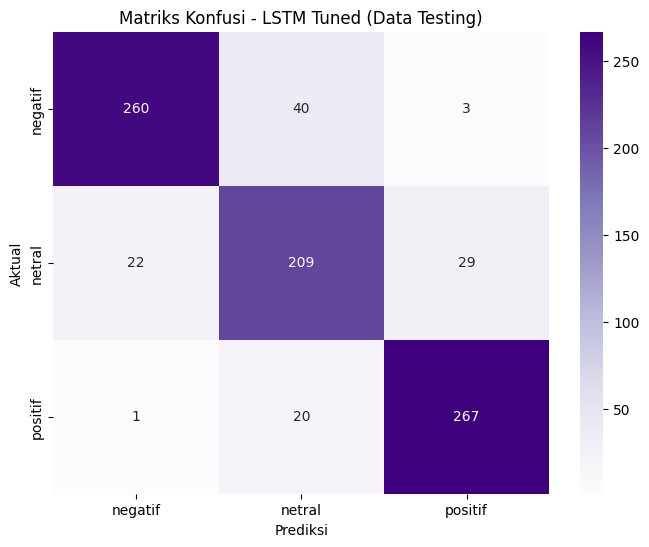

In [ ]:
best_model = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("\n📊 Skema LSTM yang Di-tuning")
print("Hyperparameter Terbaik:", best_hp.values)

# Evaluasi Akurasi
train_acc = best_model.evaluate(X_train, y_train, verbose=0)[1]
val_acc = best_model.evaluate(X_val, y_val, verbose=0)[1]
test_acc = best_model.evaluate(X_test, y_test, verbose=0)[1]

print(f"\nAkurasi Pelatihan : {train_acc:.4f}")
print(f"Akurasi Validasi  : {val_acc:.4f}")
print(f"Akurasi Pengujian : {test_acc:.4f}")

pred_lstm = np.argmax(best_model.predict(X_test), axis=1)

print("\nLaporan Klasifikasi (Data Testing):")
print(classification_report(y_test, pred_lstm, target_names=label_encoder.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, pred_lstm), annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriks Konfusi - LSTM Tuned (Data Testing)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [73]:
model_save_path = '/content/drive/My Drive/all_data/best_lstm_model.keras'
best_model.save(model_save_path)
print(f"✅ Model LSTM terbaik berhasil disimpan di: {model_save_path}")

✅ Model LSTM terbaik berhasil disimpan di: /content/drive/My Drive/all_data/best_lstm_model.keras


In [74]:
tokenizer_save_path = '/content/drive/My Drive/all_data/tokenizer_lstm.pkl'
joblib.dump(tokenizer_lstm, tokenizer_save_path)
print(f"✅ Tokenizer LSTM berhasil disimpan di: {tokenizer_save_path}")

✅ Tokenizer LSTM berhasil disimpan di: /content/drive/My Drive/all_data/tokenizer_lstm.pkl


In [ ]:
from tensorflow.keras.models import load_model

# 1. Load model
loaded_model = load_model('/content/drive/My Drive/all_data/best_lstm_model.keras')
loaded_tokenizer = joblib.load('/content/drive/My Drive/all_data/tokenizer_lstm.pkl')

ulasan_baru = ["Program makan bergizi gratis ini sangat membantu gizi anak sekolah.",
               "Anggarannya rawan dikorupsi tikus kantor"]


sequences_baru = loaded_tokenizer.texts_to_sequences(ulasan_baru)
padded_baru = pad_sequences(sequences_baru, maxlen=100)

prediksi = loaded_model.predict(padded_baru)
kategori_prediksi = np.argmax(prediksi, axis=1)

label_asli = label_encoder.inverse_transform(kategori_prediksi)

for teks, sentimen in zip(ulasan_baru, label_asli):
    print(f"Ulasan: {teks} -> Sentimen: {sentimen}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 24 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step
Ulasan: Program makan bergizi gratis ini sangat membantu gizi anak sekolah. -> Sentimen: positif
Ulasan: Anggarannya rawan dikorupsi tikus kantor -> Sentimen: negatif
